<h1>Sentimentality Prediction with Twitter Posts</h1>

<p>Our goal in this notebook, is to build a model that can determine the sentimentality of the given post, given its text content. This will involve lots of text preprocessing like tokenising and padding, and also building a recurrent neural network</p>
<p>The dataset used is from <a href="https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01">kaggle</a></p>

<p>First, let's download the datasets necessary, the train and validation set they provided</p>

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def load_n_format_df(path):
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "jp797498e/twitter-entity-sentiment-analysis",
        path,
        pandas_kwargs={"names": ['Tweet ID', 'Entity', 'Sentiment', 'Content']}
    )

    return df

In [4]:
train_df_orig = load_n_format_df("twitter_training.csv")
valid_df = load_n_format_df("twitter_validation.csv")

/tmp/ipykernel_18734/3041100087.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.


/tmp/ipykernel_18734/3041100087.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.


In [5]:
train_df = train_df_orig.copy()

In [6]:
train_df.head()

,Tweet ID,Entity,Sentiment,Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


<h3>Preprocessing</h3>
<p>Before dealing with the tokenization of the words, let's deal with missing values and things like that</p>

In [7]:
train_df.shape

(74682, 4)

In [8]:
train_df.isnull().sum()

,0
Tweet ID,0
Entity,0
Sentiment,0
Content,686


<p>We will remove the rows with the missing values for content, since we are using content, and also there aren't many values missing in comparison with the entire dataset</p>

In [9]:
train_df = train_df.dropna(subset=['Content'])

In [10]:
train_df.dtypes

,0
Tweet ID,int64
Entity,object
Sentiment,object
Content,object


<p>Sentiment is the variable we are trying to predict. Let's first look at the different occurances of each class</p>

In [11]:
train_df.Sentiment.value_counts(normalize=True)

,proportion
Sentiment,
Negative,0.302151
Positive,0.279137
Neutral,0.244716
Irrelevant,0.173996


<p>Classes seem balanced. This is what we want</p>

<p>Let's map each unique value of the sentiment feature to it's own integer value</p>

In [12]:
sentiment_map = {col: i for i, col in enumerate(train_df.Sentiment.unique())}
train_df.Sentiment = train_df.Sentiment.map(sentiment_map)

<p>Looking at the value counts to confirm that the mapping worked successfully</p>

In [13]:
train_df.Sentiment.value_counts(normalize=True)

,proportion
Sentiment,
2,0.302151
0,0.279137
1,0.244716
3,0.173996


In [14]:
target = 'Sentiment'

In [15]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
import string
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

<h3>Word Tokenizing</h3>
<p>We now want to focusing on tokenizing each phrase. Let's look at a sample phrase</p>

In [16]:
lengths = train_df.Content.str.split().apply(len)

In [17]:
sample_i = 0
sample_phrase = train_df.iloc[sample_i, :]['Content']

<p>Now, we have to decide whether punctuation is important at deciding sentimentality. Let's remove punctuation for now</p>

In [18]:
def remove_punctuation(phrase):
    return ''.join([c for c in phrase if c not in string.punctuation])

no_punc = remove_punctuation(sample_phrase)

<p>And also make all words in the sentence lowercase and strip</p>

<p>We also want to remove words that will not help with deciding sentimentality</p>

In [19]:
def remove_stopwords(phrase):
    lst_phrase = phrase.split(" ")
    return ' '.join([w for w in lst_phrase if w.lower() not in stopwords.words("english")])

In [20]:
no_stopwords = remove_stopwords(no_punc)
no_stopwords

'im getting borderlands murder '

<p>So now we know that it works on a sample text, let's apply this preprocessing pipeline to the entire dataset</p>

In [21]:
def preprocess_text(phrase):
    return remove_stopwords(remove_punctuation(phrase.lower().strip()))

In [22]:
preprocess_text(sample_phrase)

'im getting borderlands murder '

In [23]:

train_df['PreprocessedText'] = train_df.Content.apply(preprocess_text)

In [24]:
train_df.head()

,Tweet ID,Entity,Sentiment,Content,PreprocessedText
0,2401,Borderlands,0,im getting on borderlands and i will murder yo...,im getting borderlands murder
1,2401,Borderlands,0,I am coming to the borders and I will kill you...,coming borders kill
2,2401,Borderlands,0,im getting on borderlands and i will kill you ...,im getting borderlands kill
3,2401,Borderlands,0,im coming on borderlands and i will murder you...,im coming borderlands murder
4,2401,Borderlands,0,im getting on borderlands 2 and i will murder ...,im getting borderlands 2 murder


<p>Let's tokenize the texts</h3>

In [25]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df['PreprocessedText'].apply(lambda x: x.strip().split(' ')))

In [26]:
X_tokenized = tokenizer.texts_to_sequences(train_df['PreprocessedText'].apply(lambda x: x.strip().split(' ')))

In [28]:
train_df['Length'] = [len(w) for w in X_tokenized]

In [29]:
train_df.head()

,Tweet ID,Entity,Sentiment,Content,PreprocessedText,Length
0,2401,Borderlands,0,im getting on borderlands and i will murder yo...,im getting borderlands murder,4
1,2401,Borderlands,0,I am coming to the borders and I will kill you...,coming borders kill,3
2,2401,Borderlands,0,im getting on borderlands and i will kill you ...,im getting borderlands kill,4
3,2401,Borderlands,0,im coming on borderlands and i will murder you...,im coming borderlands murder,4
4,2401,Borderlands,0,im getting on borderlands 2 and i will murder ...,im getting borderlands 2 murder,5


In [30]:
train_df['Length'].describe()

,Length
count,73996.000000
mean,11.954362
std,8.826262
min,1.000000
25%,5.000000
50%,10.000000
75%,17.000000
max,163.000000


<p>Let's pad and truncate all phrase to have the 75% percentile amount of words (17 words), so the model has a fixed number of words to deal with</p>

In [31]:
maxlen = int(train_df['Length'].quantile(0.75))
X_padded = pad_sequences(X_tokenized, maxlen=maxlen)

In [32]:
train_df

,Tweet ID,Entity,Sentiment,Content,PreprocessedText,Length
0,2401,Borderlands,0,im getting on borderlands and i will murder yo...,im getting borderlands murder,4
1,2401,Borderlands,0,I am coming to the borders and I will kill you...,coming borders kill,3
2,2401,Borderlands,0,im getting on borderlands and i will kill you ...,im getting borderlands kill,4
3,2401,Borderlands,0,im coming on borderlands and i will murder you...,im coming borderlands murder,4
4,2401,Borderlands,0,im getting on borderlands 2 and i will murder ...,im getting borderlands 2 murder,5
...,...,...,...,...,...,...
74677,9200,Nvidia,0,Just realized that the Windows partition of my...,realized windows partition mac like 6 years be...,12
74678,9200,Nvidia,0,Just realized that my Mac window partition is ...,realized mac window partition 6 years behind n...,12
74679,9200,Nvidia,0,Just realized the windows partition of my Mac ...,realized windows partition mac 6 years behind ...,12
74680,9200,Nvidia,0,Just realized between the windows partition of...,realized windows partition mac like 6 years be...,16


In [33]:
train_df[[str(i + 1) for i in range(maxlen)]] = X_padded

<p>Let's create a Preprocessor class to do the preprocessing for us, so we can just reuse it for the validation data set as well</p>

In [37]:
class Preprocessor():
  def __init__(self, maxlen=10, tokenizer=Tokenizer(), y_vals_unique=np.array([])):
    self.maxlen = maxlen

    self.tokenizer = tokenizer
    self.y_vals_unique=y_vals_unique

  def __remove_nulls(self, df):
    return df.dropna(subset=['Content'])

  def __preprocess_text(self, phrase):
    """Removes punctuation and stopwords from a given phrase"""
    no_punc = ''.join([c for c in phrase if c not in string.punctuation])
    stripped = phrase.lower().strip()

    lst_phrase = phrase.split(" ")
    no_stopwords =  ' '.join([w for w in lst_phrase if w.lower() not in stopwords.words("english")])

    return no_stopwords

  def __tokenize(self, df, fit=False):
    # Fit the tokenizer if we desire
    if fit:
        self.tokenizer.fit_on_texts(df['PreprocessedText'].apply(lambda x: x.strip().split(' ')))

    X_tokenized = self.tokenizer.texts_to_sequences(df['PreprocessedText'].apply(lambda x: x.strip().split(' ')))
    return X_tokenized

  def __pad(self, tokenized_sequences):
    return pad_sequences(tokenized_sequences, maxlen=self.maxlen)

  def transform(self, orig_df, fit=False):
    """Fit and preprocess on the dataset used for training a model"""
    df = orig_df.copy()

    df = self.__remove_nulls(df)
    df['PreprocessedText'] = df.Content.apply(self.__preprocess_text)

    tokenized = self.__tokenize(df, fit)
    X_padded = self.__pad(tokenized)

    df[[str(i + 1) for i in range(self.maxlen)]] = X_padded

    if fit:
      self.y_vals_unique = df.Sentiment.unique()

    sentiment_map = {col: i for i, col in enumerate(self.y_vals_unique)}
    df.Sentiment = df.Sentiment.map(sentiment_map)
    return df


In [38]:
preprocessor = Preprocessor(maxlen)
train_df_preprocessed = preprocessor.transform(train_df_orig, True)
valid_df_preprocessed = preprocessor.transform(valid_df)

In [39]:
y_vals = train_df_orig.Sentiment.unique()
y_vals

array(['Positive', 'Neutral', 'Negative', 'Irrelevant'], dtype=object)

<h3>Model building</h3>

In [57]:
from sklearn.model_selection import train_test_split

<p>Split the train and test dataset</p>

In [55]:
X_train = train_df_preprocessed.loc[:, [str(i + 1) for i in range(maxlen)]]
y_train = train_df_preprocessed[target]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [62]:
X_valid = valid_df_preprocessed.loc[:, [str(i + 1) for i in range(maxlen)]]
y_valid = valid_df_preprocessed[target]

<p>Building the model. We have an Embedding layer to convert our tokenized texts into a vector of different values. <br>
Then we create a GRU (Gate Recurrent Unit) which is a simpler and faster to train version of LSTMs.
<br>We finally add a Dense layer with softmax activation that gives us a probability score of an instance belong to each class</p>

In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

num_words = len(preprocessor.tokenizer.index_word) + 1

model = Sequential()
model.add(Embedding(input_dim=num_words, output_dim=128))
model.add(GRU(16))
model.add(Dense(4, activation='softmax', dtype='float32'))

In [67]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

<p>Training the model. We will train with 10 epochs with early stopping, so that training can be stopped early if the validation score doesn't improve after 3 epochs as defined below</p>

In [68]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    validation_data=(X_valid, y_valid),
                    batch_size=32,
                    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)])

Epoch 1/10
2082/2082 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.6953 - loss: 0.7667 - val_accuracy: 0.9380 - val_loss: 0.2127
Epoch 2/10
2082/2082 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9275 - loss: 0.2028 - val_accuracy: 0.9520 - val_loss: 0.1480
Epoch 3/10
2082/2082 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9568 - loss: 0.1102 - val_accuracy: 0.9610 - val_loss: 0.1460
Epoch 4/10
2082/2082 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9665 - loss: 0.0822 - val_accuracy: 0.9560 - val_loss: 0.1546
Epoch 5/10
2082/2082 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9705 - loss: 0.0685 - val_accuracy: 0.9570 - val_loss: 0.1655
Epoch 6/10
2082/2082 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9728 - loss: 0.0609 - val_accuracy: 0.9560 - val_loss: 0.1592


<p>Looks like we have some decent results in terms of accuracy and validation accuracy. This shows that we haven't overfitten the model. However, we cannot be too sure with just one metric. We should also use other metrics</p>

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

y_pred = model.predict(X_test)

232/232 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [78]:
scalar_pred = y_pred.argmax(axis=1)

<p>Now let's display the confusion matrix. This will show us how many instances were classified correctly and misclassified</p>

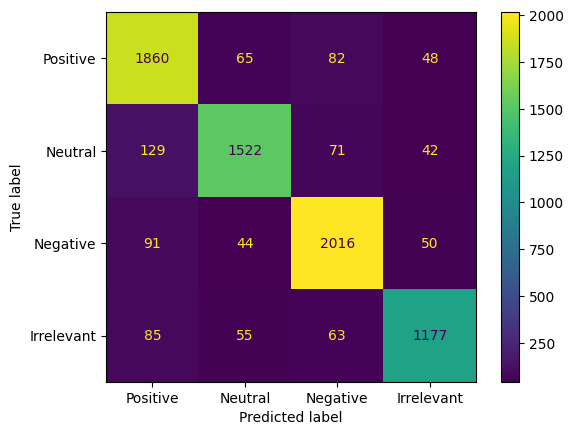

In [79]:

conf_matrix = confusion_matrix(y_test, scalar_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=preprocessor.y_vals_unique)
disp.plot()

<p>Results seem good, because also the classes are nicely balanced</p>

<p>Now let's check out precision, recall, and f1-score</p>

In [81]:
print(classification_report(y_test, scalar_pred))

              precision    recall  f1-score   support

           0       0.86      0.91      0.88      2055
           1       0.90      0.86      0.88      1764
           2       0.90      0.92      0.91      2201
           3       0.89      0.85      0.87      1380

    accuracy                           0.89      7400
   macro avg       0.89      0.88      0.89      7400
weighted avg       0.89      0.89      0.89      7400



<p>Results seem goods. The weighted F1 Score is 0.89, showing us that we have a good classifier of sentimentality given the content of a twitter post</p>